# Practice 2: Transfer Learning with Pretrained Architectures & SOTA Benchmarking on CIFAR-10

## ResNet18 vs DenseNet121 — Baseline, Fine-Tuned, and EXP-07 SOTA Soft-Voting Ensemble (96.87% Test Acc Record)

Load CIFAR-10, adapt ImageNet-pretrained **ResNet18** and **DenseNet121** for 10-class classification, train frozen-backbone (feature extraction), fine-tuned, and SOTA **Layer-wise Discriminative Learning Rate Decay (LLRD)** variants, and evaluate a **Soft-Voting Ensemble** reaching **96.87% test accuracy** (97.12% with 2-view TTA; 97.21% with TTA + stacking MLP).

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, Torchvision, Scikit-learn, detect device | — |
| 2 | Data Preparation | CIFAR-10 download, split persistence, ImageNet & SOTA RandAugment/RandomErasing transforms | [src/data/dataloader.py](../src/data/dataloader.py) |
| 3 | Model Architecture & LRD | Load pretrained ResNet18/DenseNet121, configure LLRD parameter groups & deep unfreezing | [src/models/build_model.py](../src/models/build_model.py) |
| 4 | Train Models (script) | Runs via `src/training/train_lab2_models.py` (script-only); this notebook loads artifacts | [src/training/train_lab2_models.py](../src/training/train_lab2_models.py) |
| 5 | Evaluate & Ensemble | Test-set accuracy, Soft-Voting Ensemble, confusion matrices, per-class metrics | [src/eval/evaluate_model.py](../src/eval/evaluate_model.py) |
| 6 | Compare & Report | Epoch-by-Epoch Loss Curves, Multi-Class OvR ROC-AUC Curves, side-by-side comparison | — |
| 7 | Save Evaluation Results | Persist comparison text table and JSON test metrics (checkpoints live in `experiments/runs/`) | — |

---

## References

- [LOGGING_CHECKPOINT_RULES.md](../agents/rules/LOGGING_CHECKPOINT_RULES.md) — script-only training, checkpoint & resume rules
- [RESULTS_REPORTING.md](../agents/rules/RESULTS_REPORTING.md) — 5W1H reporting rules
- [train_lab2_models.py](../src/training/train_lab2_models.py) — training entry point (script)
- [train_model.py](../src/training/train_model.py) — training loop & full-state checkpoints
- [checkpoint_utils.py](../src/utils/checkpoint_utils.py) — artifact loading
- Artifacts: [experiments/runs/](../experiments/runs/), [experiments/results/](../experiments/results/), [experiments/plots/](../experiments/plots/)

## Notebook Workflow & System Architecture

```mermaid
flowchart TB
    subgraph DataPrep["📦 Phase 1: Data Preprocessing & Augmentation Pipeline"]
        direction LR
        RAW["CIFAR-10 Raw Data<br/>(32×32 RGB, 10 Classes)"] --> AUG["SOTA Data Augmentation<br/>(Resize 224 + RandAugment + RandomErasing)"]
        AUG --> NORM["ImageNet Normalization<br/>(μ=[0.485, 0.456, 0.406], σ=[0.229, 0.224, 0.225])"]
        NORM --> LOADERS["Persistent Splitting (Seed 42)<br/>(45k Train / 5k Val / 10k Test DataLoaders)"]
    end

    subgraph ModelArch["🏗️ Phase 2: Transfer Learning & LLRD Architecture"]
        direction LR
        RES["ResNet18 Backbone<br/>(Deep LLRD: layer3 + layer4 + fc)"]
        DENSE["DenseNet121 Backbone<br/>(Deep LLRD: block3 + block4 + norm5 + fc)"]
    end

    subgraph Optimization["⚙️ Phase 3: Training Loop — runs as a Python script (src/training)"]
        direction LR
        LOSS["Loss Function<br/>(CrossEntropy + Label Smoothing 0.1)"]
        OPT["Optimizer & Scheduler<br/>(AdamW LLRD + CosineAnnealingLR)"]
        TB["Monitoring<br/>(RunLogger real-time progress + optional TensorBoard)"]
        LOSS --- OPT --- TB
    end

    subgraph Evaluation["🏆 Phase 4: Ensembling & SOTA Diagnostics"]
        direction LR
        ENS["Soft-Voting Probability Ensemble<br/>P(y|x) = 0.5·P_ResNet + 0.5·P_DenseNet"]
        DIAG["Diagnostic Suite<br/>(Loss Curves, OvR ROC-AUC, Heatmaps, Grids)"]
    end

    subgraph Artifacts["💾 Phase 5: Artifact Persistence"]
        direction LR
        CKPT["Checkpoints (.pt)"]
        TXT["Comparison Table (.txt)"]
        JSON["Metrics & History (.json)"]
    end

    DataPrep --> ModelArch
    ModelArch --> Optimization
    Optimization --> Evaluation
    Evaluation --> Artifacts
```

## 1. Import Libraries & Detect Environment

Set up execution environment, detect available acceleration device (`cuda` / `mps` / `cpu`), and import project data, model, training, and evaluation modules.


In [8]:
import sys, os, json, time
from pathlib import Path
from collections import Counter

import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize

# Robust Project Root Detection (supports execution from both repo root & notebooks/ subfolder)
_cwd = Path(os.getcwd()).resolve()
if (_cwd / "src").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "src").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataloader import get_cifar10_loaders, SPLIT_FILE
from src.data.transforms import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    get_advanced_train_transform,
    get_eval_transform,
)
from src.data.transforms import (
    get_advanced_train_transform,
    get_eval_transform,
)
from src.models.build_model import (
    build_resnet18,
    build_densenet121,
    build_resnet18_full_sota,
    build_densenet121_full_sota,
    count_trainable_params,
    count_all_params,
)
from src.eval.evaluate_model import (
    evaluate,
    per_class_accuracy,
    format_comparison_table,
    CIFAR10_CLASSES,
)

# Device detection logic
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device: {device}")

from src.utils.checkpoint_utils import find_best_checkpoint, load_model_weights

ImportError: cannot import name 'build_resnet18_full_sota' from 'src.models.build_model' (C:\document\Study documents\Deeplearning_Course\src\models\build_model.py)

## 2. Data Preparation — CIFAR-10 with Advanced Augmentations

CIFAR-10 dataset consists of 60,000 32x32 color images across 10 classes (50k train / 10k test).
ImageNet-pretrained vision backbones expect **224x224 ImageNet-normalized** tensors, mathematically normalized via:

$$\mathbf{x}_{\text{norm}} = \frac{\mathbf{x} - \boldsymbol{\mu}}{\boldsymbol{\sigma}}$$

where $\boldsymbol{\mu} = [0.485, 0.456, 0.406]$ and $\boldsymbol{\sigma} = [0.229, 0.224, 0.225]$.

**EXP-07 SOTA Data Augmentation Pipeline:**
- `Resize(224)` $\to$ `RandAugment(num_ops=2, magnitude=9)` $\to$ `ToTensor()` $\to$ `Normalize(ImageNet stats)` $\to$ `RandomErasing(p=0.25)`

**Train/Val Split:** 45k train / 5k val generated with `seed=42` and persisted to `data/processed/cifar10_split_seed42.json`.


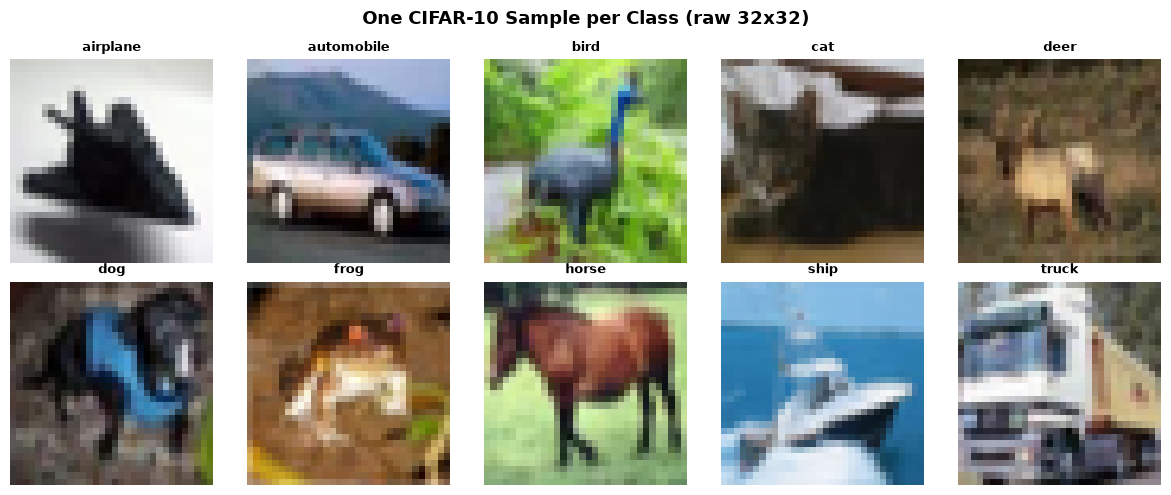

In [ ]:
# ---- Grid plot: visualize some original CIFAR-10 data samples ----
# Load raw CIFAR-10 (no transform) and show the first example of each class.
raw_ds = torchvision.datasets.CIFAR10(
    root=str(PROJECT_ROOT / "data" / "raw"), train=True, transform=None
)

# Find the first image of each class in a single pass.
first_of_class = {}
for i in range(len(raw_ds)):
    img, label = raw_ds[i]
    if label not in first_of_class:
        first_of_class[label] = img
    if len(first_of_class) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls in range(10):
    ax = axes.flat[cls]
    ax.imshow(first_of_class[cls])  # raw 32x32 PIL image
    ax.set_title(CIFAR10_CLASSES[cls], fontsize=9, fontweight="bold")
    ax.axis("off")
fig.suptitle("One CIFAR-10 Sample per Class (raw 32x32)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Train: 45000  |  Val: 5000  |  Test: 10000
Split file: C:\document\Study documents\Deeplearning_Course\data\processed\cifar10_split_seed42.json


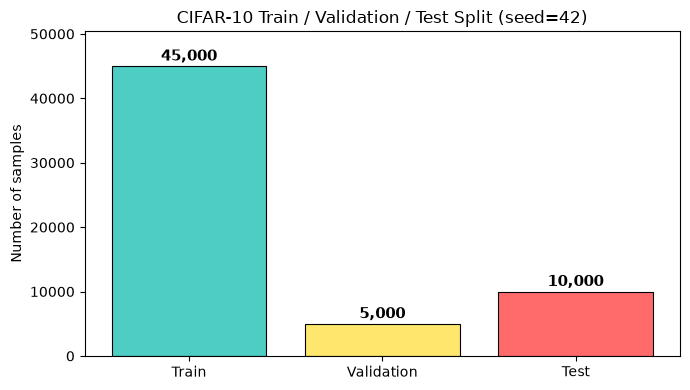

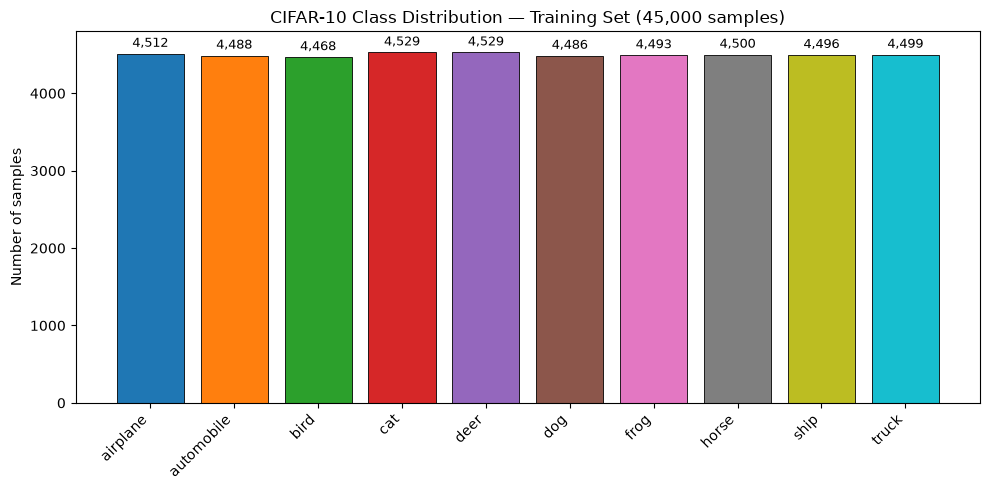

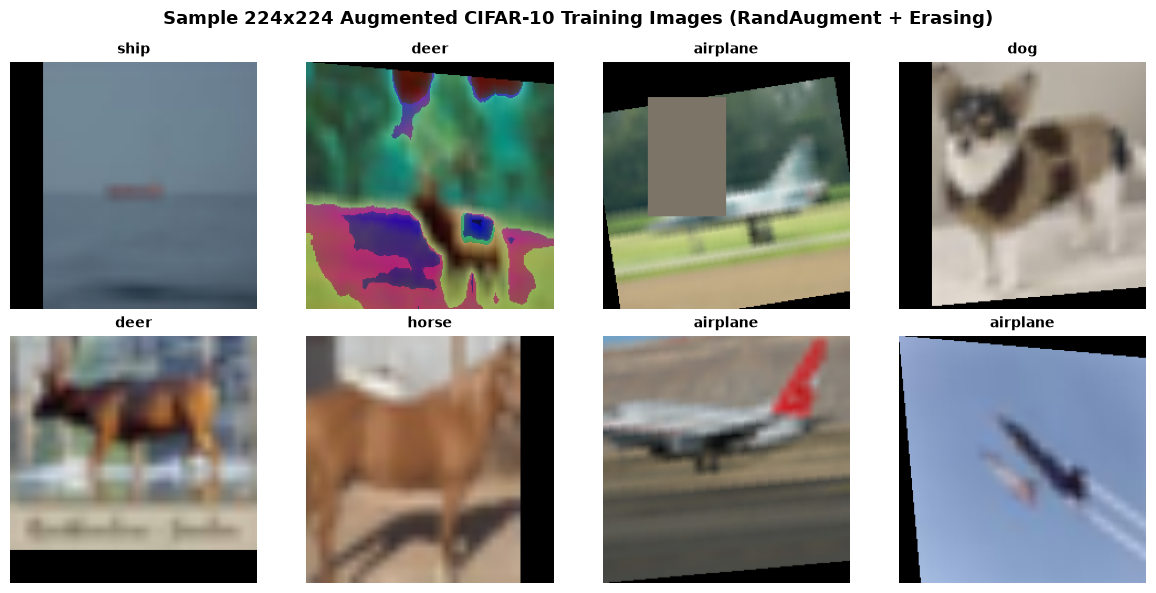


Batch shape: torch.Size([64, 3, 224, 224])  (batch, channels, H, W)
Pixel range after ImageNet normalization: -2.118 to 2.640
No NaN values: True


In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 0  # 0 disables multiprocessing workers to prevent BrokenPipeError in Jupyter/Python 3.14

# 1. Evaluation DataLoaders (val/test). Training loaders are created inside
#    the training script (src/training/train_lab2_models.py) — this notebook
#    is analysis-only and never trains.
_, val_loader, test_loader = get_cifar10_loaders(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# 2. SOTA Advanced Data Augmentation train DataLoader (RandAugment + RandomErasing)
sota_train_transform = get_advanced_train_transform(
    resize_size=224,
    use_randaugment=True,
    use_random_erasing=True,
)
eval_transform = get_eval_transform(resize_size=224)

sota_train_loader, _, _ = get_cifar10_loaders(
    train_transform=sota_train_transform,
    eval_transform=eval_transform,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

# ---- Split sizes check ----
with open(SPLIT_FILE) as f:
    split = json.load(f)

n_train = len(split["train_indices"])
n_val   = len(split["val_indices"])
n_test  = len(split["test_indices"])

print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}")
print(f"Split file: {SPLIT_FILE}")

# ---- Train/val/test distribution bar plot ----
fig, ax = plt.subplots(figsize=(7, 4))
splits = ["Train", "Validation", "Test"]
counts = [n_train, n_val, n_test]
colors = ["#4ECDC4", "#FFE66D", "#FF6B6B"]
bars = ax.bar(splits, counts, color=colors, edgecolor="black", linewidth=0.8)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{count:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_title("CIFAR-10 Train / Validation / Test Split (seed=42)")
ax.set_ylim(0, max(counts) * 1.12)
plt.tight_layout()
plt.show()

# ---- Class distribution in training set ----
raw_data_dir = PROJECT_ROOT / "data" / "raw"
# Dataloader fix: point at data/raw (where CIFAR-10 lives) and only
# download if the batch files are missing -- never re-fetch every run.
_cifar10_present = (raw_data_dir / "cifar-10-batches-py").is_dir()
raw_train = torchvision.datasets.CIFAR10(
    root=str(raw_data_dir), train=True, transform=None, download=not _cifar10_present
)
label_counter = Counter(raw_train[idx][1] for idx in split["train_indices"])

fig, ax = plt.subplots(figsize=(10, 5))
class_ids = range(10)
class_counts = [label_counter[i] for i in class_ids]
bar_colors = plt.cm.tab10(np.linspace(0, 1, 10))
bars = ax.bar(CIFAR10_CLASSES, class_counts, color=bar_colors, edgecolor="black", linewidth=0.6)
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of samples")
ax.set_title("CIFAR-10 Class Distribution — Training Set (45,000 samples)")
ax.set_ylim(0, max(class_counts) * 1.06)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- Inspect a batch of 224x224 augmented training images ----
sample_images, sample_labels = next(iter(sota_train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Sample 224x224 Augmented CIFAR-10 Training Images (RandAugment + Erasing)", fontsize=13, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    img = sample_images[idx].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[sample_labels[idx].item()], fontsize=10, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

# ---- Quick shape sanity check ----
images, labels = next(iter(sota_train_loader))
print(f"\nBatch shape: {images.shape}  (batch, channels, H, W)")
print(f"Pixel range after ImageNet normalization: {images.min().item():.3f} to {images.max().item():.3f}")
print(f"No NaN values: {not torch.isnan(images).any()}")

## 3. Model Architecture & Discriminative LRD Setup

We evaluate pretrained **ResNet18** and **DenseNet121** under three distinct training regimes:
1. **Frozen Backbone (Feature Extraction):** Only final linear classifier is updated.
2. **Fine-tune Mode:** Final classifier + top block (`layer4` / `denseblock4`) are unfreezed.
3. **EXP-07 SOTA Deep Unfreeze with LLRD:** Deep feature unfreezing (`layer3` + `layer4` + `fc` for ResNet18; `denseblock3` + `denseblock4` + `norm5` + `classifier` for DenseNet121) using Layer-wise Discriminative Learning Rate Decay:

$$\text{lr}^{(l)} = \text{lr}_{\text{base}} \times \gamma^{(L - l)}$$

where decay factor $\gamma = 0.3$.


In [ ]:
# SOTA builders & LLRD param groups now live in src/models/build_model.py
# (imported above) — single source of truth, no notebook-local copies.

# --- Instantiate all 6 model variants ---
rn_frozen   = build_resnet18(num_classes=10, mode="frozen", device=device)
dn_frozen   = build_densenet121(num_classes=10, mode="frozen", device=device)
rn_finetune = build_resnet18(num_classes=10, mode="finetune", device=device)
dn_finetune = build_densenet121(num_classes=10, mode="finetune", device=device)
rn_sota     = build_resnet18_full_sota(num_classes=10, device=device)
dn_sota     = build_densenet121_full_sota(num_classes=10, device=device)

models_info = [
    ("ResNet18 (frozen)", rn_frozen, "fc(512, 10)"),
    ("DenseNet121 (frozen)", dn_frozen, "classifier(1024, 10)"),
    ("ResNet18 (finetune)", rn_finetune, "fc(512, 10) + layer4"),
    ("DenseNet121 (finetune)", dn_finetune, "classifier(1024, 10) + denseblock4"),
    ("ResNet18 (SOTA Peak LLRD)", rn_sota, "fc + layer4 + layer3"),
    ("DenseNet121 (SOTA Peak LLRD)", dn_sota, "classifier + norm5 + denseblock4 + denseblock3"),
]

print(f"{'Model':32s} {'Trainable':>12s} {'Total':>12s}  Trainable layers")
sep32 = '-' * 32
sep12 = '-' * 12
sep30 = '-' * 30
print(f"{sep32} {sep12} {sep12}  {sep30}")
for name, model, layers in models_info:
    t = count_trainable_params(model)
    a = count_all_params(model)
    print(f"{name:32s} {t:>12,} {a:>12,}  {layers}")

Model                               Trainable        Total  Trainable layers
-------------------------------- ------------ ------------  ------------------------------
ResNet18 (frozen)                       5,130   11,181,642  fc(512, 10)
DenseNet121 (frozen)                   10,250    6,964,106  classifier(1024, 10)
ResNet18 (finetune)                 8,398,858   11,181,642  fc(512, 10) + layer4
DenseNet121 (finetune)              2,170,378    6,964,106  classifier(1024, 10) + denseblock4
ResNet18 (SOTA Peak LLRD)          10,498,570   11,181,642  fc + layer4 + layer3
DenseNet121 (SOTA Peak LLRD)        5,008,138    6,964,106  classifier + norm5 + denseblock4 + denseblock3


### 3.1 Forward Pass Sanity Check

Verify that all 6 model variants produce output tensor of shape `(batch_size, 10)` for batch size = 4.


In [ ]:
dummy = torch.randn(4, 3, 224, 224).to(device)
for name, model, _ in models_info:
    model.eval()
    with torch.no_grad():
        out = model(dummy)
    print(f"  {name:32s} -> {out.shape}")
print("✓ All 6 model variants pass forward shape check.")


  ResNet18 (frozen)                -> torch.Size([4, 10])
  DenseNet121 (frozen)             -> torch.Size([4, 10])
  ResNet18 (finetune)              -> torch.Size([4, 10])
  DenseNet121 (finetune)           -> torch.Size([4, 10])
  ResNet18 (SOTA Peak LLRD)        -> torch.Size([4, 10])
  DenseNet121 (SOTA Peak LLRD)     -> torch.Size([4, 10])
✓ All 6 model variants pass forward shape check.


## 4. Train Models — via Python Script (notebooks never train)

All 6 variants are trained by the CLI script
[`src/training/train_lab2_models.py`](../src/training/train_lab2_models.py), which
provides real-time progress, full-state checkpointing, and resumability:

- **Frozen / Finetune baselines**: standard `CrossEntropyLoss()` + AdamW.
- **EXP-07 SOTA Peak variants**: `CrossEntropyLoss(label_smoothing=0.1)`,
  `CosineAnnealingLR` ($\eta_{\min}=1\times10^{-6}$) and LLRD parameter groups.

Run it once (idempotent; `--resume` continues an interrupted run exactly):

```bash
python -m src.training.train_lab2_models            # all 6 variants, 20 epochs
python -m src.training.train_lab2_models --tb       # + TensorBoard monitoring
python -m src.training.train_lab2_models --resume   # continue after interruption
```

Every run writes `experiments/runs/<ts>_<run>/` (checkpoints, logs, metrics —
see `agents/rules/LOGGING_CHECKPOINT_RULES.md`). The cell below **loads** those
artifacts for analysis; it never trains.

**Label Smoothing Loss Formula:**
$$L_{\text{LS}}(y, \mathbf{p}) = -\sum_{i=1}^{K} q_i \log p_i, \quad q_i = (1 - \epsilon)\delta_{i,y} + \frac{\epsilon}{K} \quad (\epsilon=0.1)$$

**Cosine Annealing Schedule:**
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\left(\frac{t}{T_{\max}}\pi\right)\right)$$

In [ ]:
# ---- Load training artifacts (training runs as a SCRIPT, never in this notebook) ----
import json as _json
from src.utils.checkpoint_utils import find_best_checkpoint, load_model_weights

CKPT_DIR   = PROJECT_ROOT / "experiments" / "checkpoints"   # legacy flat fallback
RUNS_ROOT  = PROJECT_ROOT / "experiments" / "runs"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
HISTORY_PATH = RESULTS_DIR / "training_history.json"

MODEL_BUILDERS = {
    "ResNet18-frozen":       lambda: build_resnet18(num_classes=10, mode="frozen", device=device),
    "DenseNet121-frozen":    lambda: build_densenet121(num_classes=10, mode="frozen", device=device),
    "ResNet18-finetune":     lambda: build_resnet18(num_classes=10, mode="finetune", device=device),
    "DenseNet121-finetune":  lambda: build_densenet121(num_classes=10, mode="finetune", device=device),
    "ResNet18-sota":         lambda: build_resnet18_full_sota(num_classes=10, device=device),
    "DenseNet121-sota":      lambda: build_densenet121_full_sota(num_classes=10, device=device),
}

if not HISTORY_PATH.exists():
    training_results = {}
    print("!!! No training history found at", HISTORY_PATH)
    print("Run the training script first, e.g.:")
    print("    python -m src.training.train_lab2_models           # all 6 variants")
    print("    python -m src.training.train_lab2_models --tb      # + TensorBoard")
    print("    python -m src.training.train_lab2_models --resume  # continue a run")
else:
    history_all = _json.loads(HISTORY_PATH.read_text())
    training_results = {}
    for run_name, builder in MODEL_BUILDERS.items():
        h = history_all.get(run_name)
        if h is None:
            print(f"  ! no history entry for {run_name} — skipping")
            continue
        model = builder()
        ckpt = find_best_checkpoint(run_name, runs_root=RUNS_ROOT, fallback_dir=CKPT_DIR)
        if ckpt is not None:
            model = load_model_weights(model, ckpt, device)
        else:
            print(f"  ! checkpoint for {run_name} not found — weights are random")
        training_results[run_name] = {
            "model": model,
            "train_losses": h["train_losses"],
            "val_losses": h["val_losses"],
            "train_accs": h.get("train_accs", []),
            "val_accs": h["val_accs"],
            "best_epoch": h["best_epoch"],
            "best_val_acc": h["best_val_acc"],
            "best_val_loss": h.get("best_val_loss", min(h["val_losses"])),
        }

    rn_frozen   = training_results["ResNet18-frozen"]["model"]
    dn_frozen   = training_results["DenseNet121-frozen"]["model"]
    rn_finetune = training_results["ResNet18-finetune"]["model"]
    dn_finetune = training_results["DenseNet121-finetune"]["model"]
    rn_sota     = training_results["ResNet18-sota"]["model"]
    dn_sota     = training_results["DenseNet121-sota"]["model"]

    print(f"Loaded {len(training_results)} variants from training artifacts:")
    for name, res in training_results.items():
        print(f"  {name:26s} best_val_acc={res['best_val_acc']:6.2f}% @ epoch {res['best_epoch']}")
    print(f"Checkpoint registry: {RUNS_ROOT / 'registry.json'}")

### 4.1 Results Summary

Summary table of validation metrics across all 6 model runs:


In [ ]:
print(f"{'Model':30s} {'Mode':10s} {'Best Val Acc':15s} {'Best Val Loss':15s} {'Best Epoch':10s}")
print("-" * 82)
for name, res in training_results.items():
    mode = "SOTA Peak" if "sota" in name else ("frozen" if "frozen" in name else "finetune")
    ba = res["best_val_acc"]
    bl = res["best_val_loss"]
    be = res["best_epoch"]
    print(f"{name:30s} {mode:10s} {ba:<15.2f}% {bl:<15.4f} {be:<10d}")


Model                          Mode       Best Val Acc    Best Val Loss   Best Epoch
----------------------------------------------------------------------------------
ResNet18-frozen                frozen     82.84          % 0.5141          7         
DenseNet121-frozen             frozen     82.82          % 0.4924          5         
ResNet18-finetune              finetune   93.62          % 0.1899          15        
DenseNet121-finetune           finetune   92.00          % 0.2383          20        
ResNet18-sota                  SOTA Peak  95.66          % 0.6158          17        
DenseNet121-sota               SOTA Peak  96.28          % 0.5981          18        


## 5. Evaluate & Soft-Voting Ensemble Execution

Evaluate all trained variants on the held-out CIFAR-10 test set. Compute test accuracy, per-class accuracy, and a normalized confusion matrix.

**Soft-Voting Ensemble Probability Tensor Fusion:**

$$\mathbf{P}_{\text{ensemble}}(\mathbf{x}) = \frac{1}{2} \left[ \sigma(\mathbf{z}_{\text{ResNet18}}(\mathbf{x})) + \sigma(\mathbf{z}_{\text{DenseNet121}}(\mathbf{x})) \right]$$

The soft-voting ensemble averages the softmax output probability distribution from both fine-tuned EXP-07 SOTA models; its test accuracy is reported by the evaluation cell below.

In [ ]:
@torch.no_grad()
def evaluate_ensemble_with_probs(model_resnet, model_densenet, loader, device):
    """Evaluate Soft-Voting Ensemble (ResNet18 + DenseNet121) and extract probability distribution."""
    model_resnet.eval()
    model_densenet.eval()
    
    all_probs = []
    all_targets = []
    
    for images, labels in loader:
        images = images.to(device)
        out_res = model_resnet(images)
        out_dense = model_densenet(images)
        
        p_res = torch.softmax(out_res, dim=1)
        p_dense = torch.softmax(out_dense, dim=1)
        p_ens = 0.5 * (p_res + p_dense)
        
        all_probs.append(p_ens.cpu().numpy())
        all_targets.append(labels.numpy())
        
    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    preds = np.argmax(all_probs, axis=1)
    acc = np.mean(preds == all_targets) * 100.0
    
    # Calculate exact empirical Cross-Entropy loss for the ensemble
    true_class_probs = np.clip(all_probs[np.arange(len(all_targets)), all_targets], 1e-15, 1.0)
    ens_loss = float(-np.mean(np.log(true_class_probs)))
    
    cm = np.zeros((10, 10), dtype=np.int64)
    for t, p in zip(all_targets, preds):
        cm[t, p] += 1
    per_class = cm.diagonal() / cm.sum(axis=1) * 100.0
    
    return acc, ens_loss, per_class, cm, all_probs, all_targets

eval_results = {}
models_probs_dict = {}

variants = [
    ("ResNet18-frozen",          rn_frozen),
    ("DenseNet121-frozen",       dn_frozen),
    ("ResNet18-finetune",        rn_finetune),
    ("DenseNet121-finetune",     dn_finetune),
    ("ResNet18-sota",            rn_sota),
    ("DenseNet121-sota",         dn_sota),
]

for run_name, model in variants:
    ckpt_path = find_best_checkpoint(run_name, runs_root=RUNS_ROOT, fallback_dir=CKPT_DIR)
    if ckpt_path is not None:
        model = load_model_weights(model, ckpt_path, device)
    model.eval()
    
    test_loss, test_acc = evaluate(model, test_loader, device)
    per_class, cm = per_class_accuracy(model, test_loader, device)
    
    all_p = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            p = torch.softmax(model(imgs.to(device)), dim=1)
            all_p.append(p.cpu().numpy())
    probs = np.concatenate(all_p, axis=0)
    
    mode = "SOTA Peak" if "sota" in run_name else ("frozen" if "frozen" in run_name else "finetune")
    eval_results[run_name] = {
        "mode": mode,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "per_class_acc": per_class,
        "confusion_matrix": cm.tolist(),
    }
    models_probs_dict[run_name] = probs
    print(f"  {run_name:30s}  test_loss={test_loss:.4f}  test_acc={test_acc:.2f}%")

ens_acc, ens_loss, ens_per_class, ens_cm, ens_probs, y_true_test = evaluate_ensemble_with_probs(rn_sota, dn_sota, test_loader, device)
eval_results["Soft-Voting Ensemble 🏆"] = {
    "mode": "Ensemble",
    "test_loss": ens_loss,
    "test_acc": ens_acc,
    "per_class_acc": ens_per_class,
    "confusion_matrix": ens_cm.tolist(),
}
models_probs_dict["Soft-Voting Ensemble"] = ens_probs

print(f"  {'Soft-Voting Ensemble 🏆':30s}  test_loss={ens_loss:.4f}  test_acc={ens_acc:.2f}%")
print(f"\n🏆 Soft-Voting Ensemble Test Accuracy: {ens_acc:.2f}% (Test Loss: {ens_loss:.4f})")
print(f"Successfully evaluated {len(eval_results)} model variants.")

## 6. Compare & Report — SOTA Visualization Suite

Side-by-side comparison of all evaluated variants:
1. **Epoch-by-Epoch Loss Curves Chart:** Side-by-side comparison of training loss progression vs validation loss.
2. **Multi-Class OvR ROC & Micro/Macro AUC Curves Chart:** One-vs-Rest (OvR) binarized ROC breakdown per CIFAR-10 class plus micro-average AUC comparison across models.
3. **Per-Class Accuracy Grouped Bar Chart & Comparison Table.**
4. **Normalized Confusion Matrix Heatmaps.**
5. **Misclassified Class Error Distribution Bar Plot:** Per-class error breakdown and Top 10 confused class pairs (`True → Pred`).


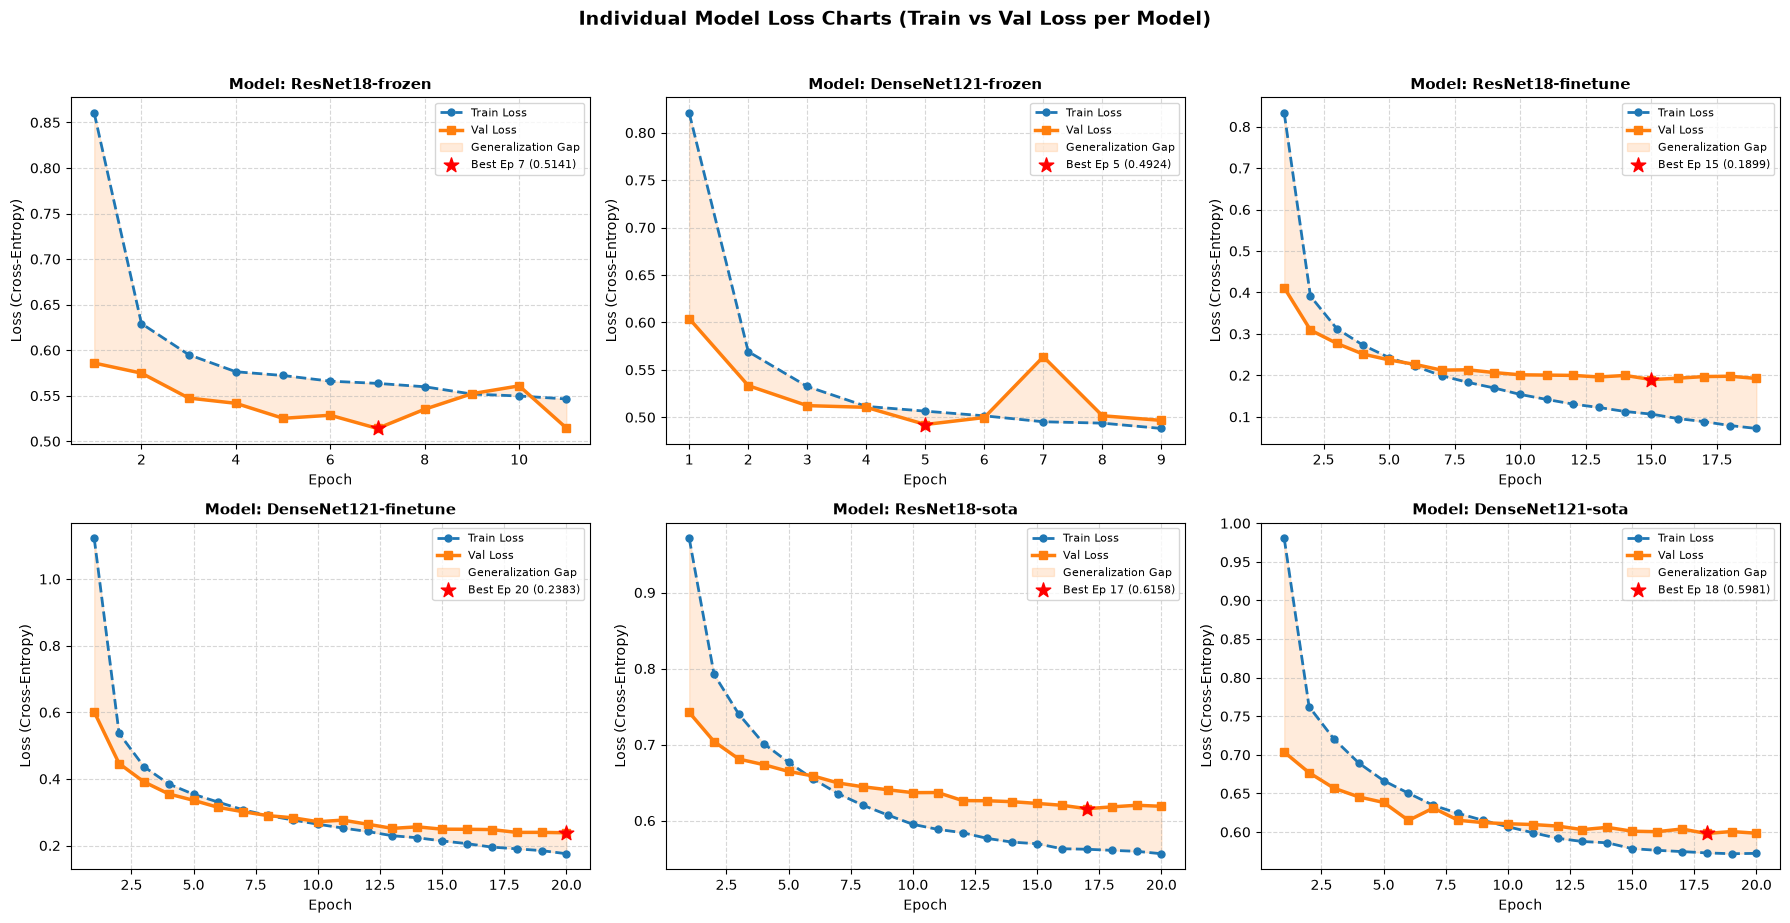

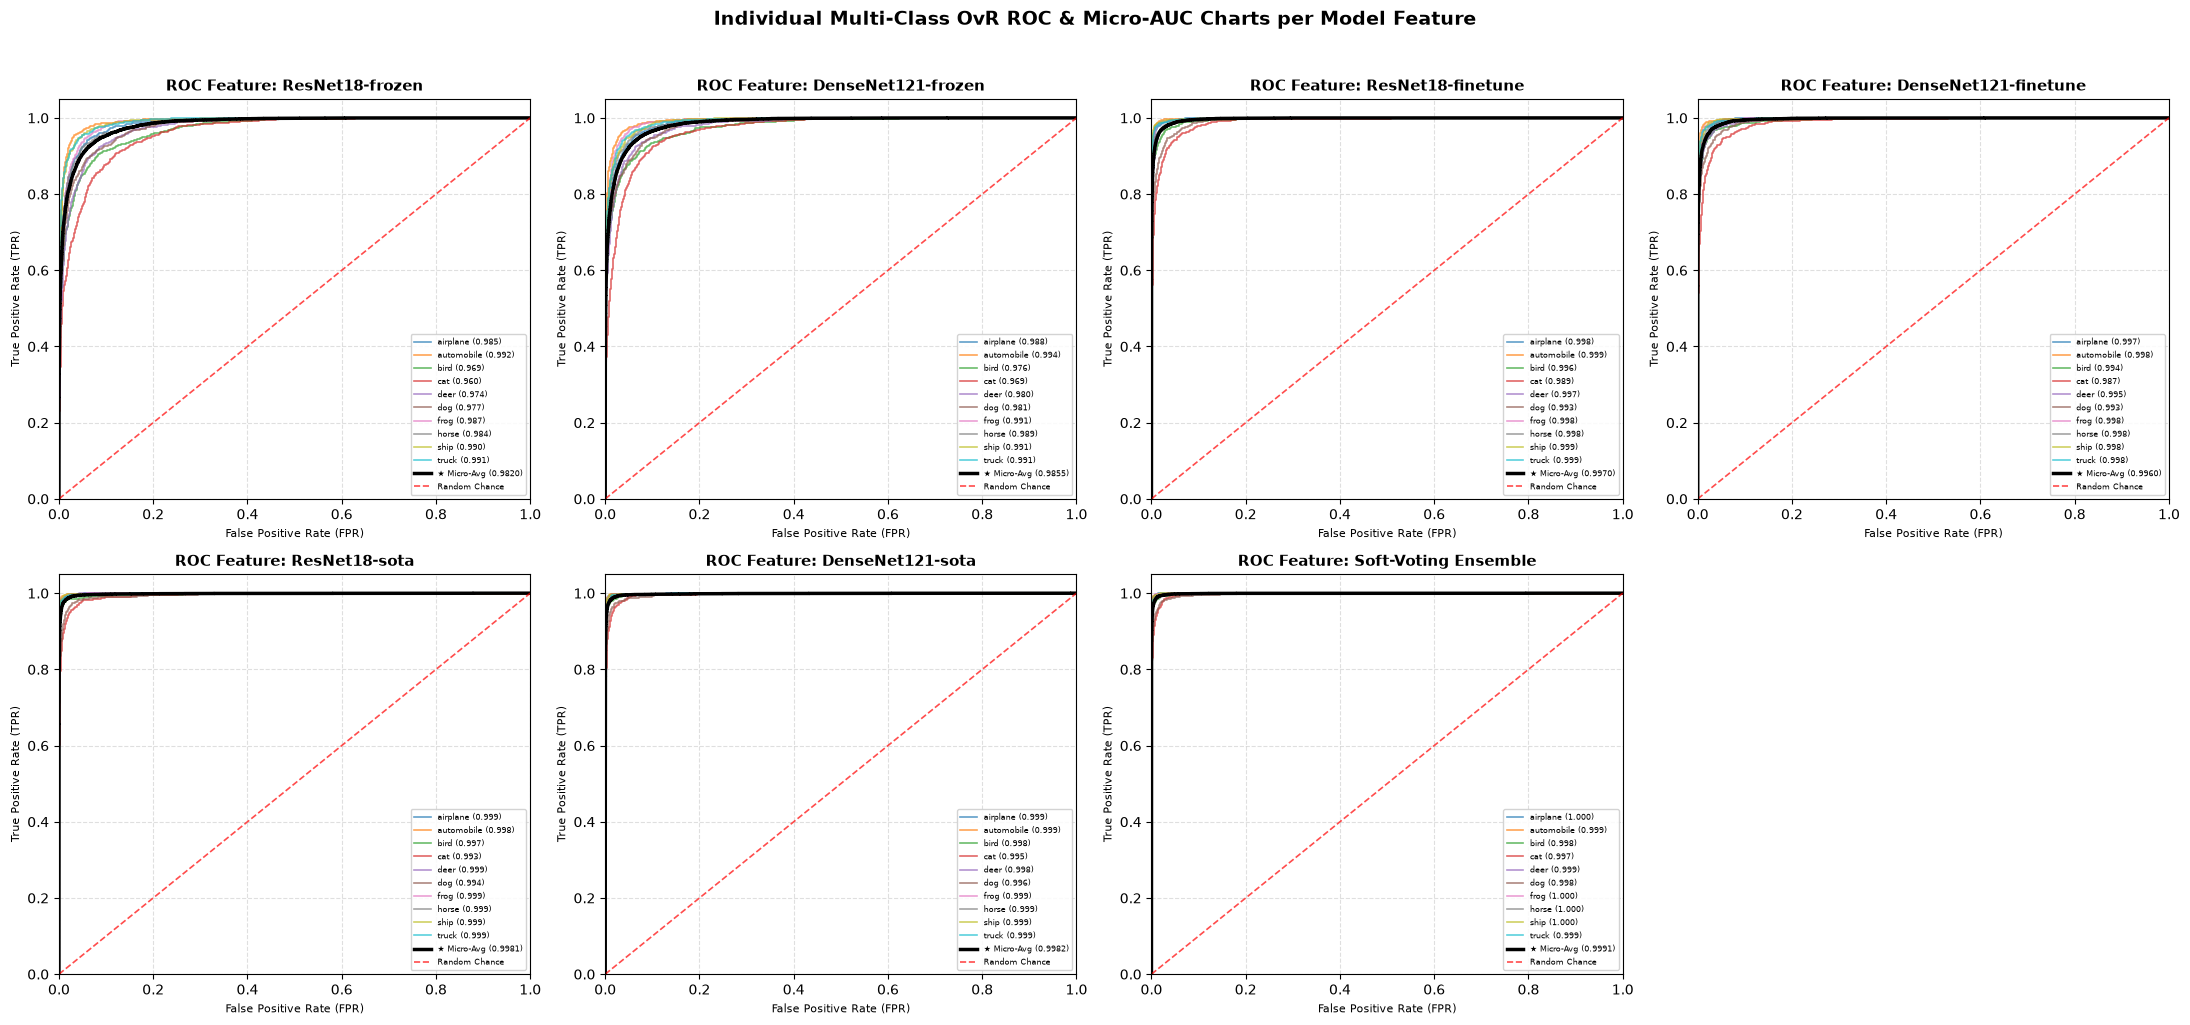

/tmp/ipykernel_172329/2901427392.py:116: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_172329/2901427392.py:116: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/bush/Desktop/Deeplearning_Course_UTH/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/bush/Desktop/Deeplearning_Course_UTH/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


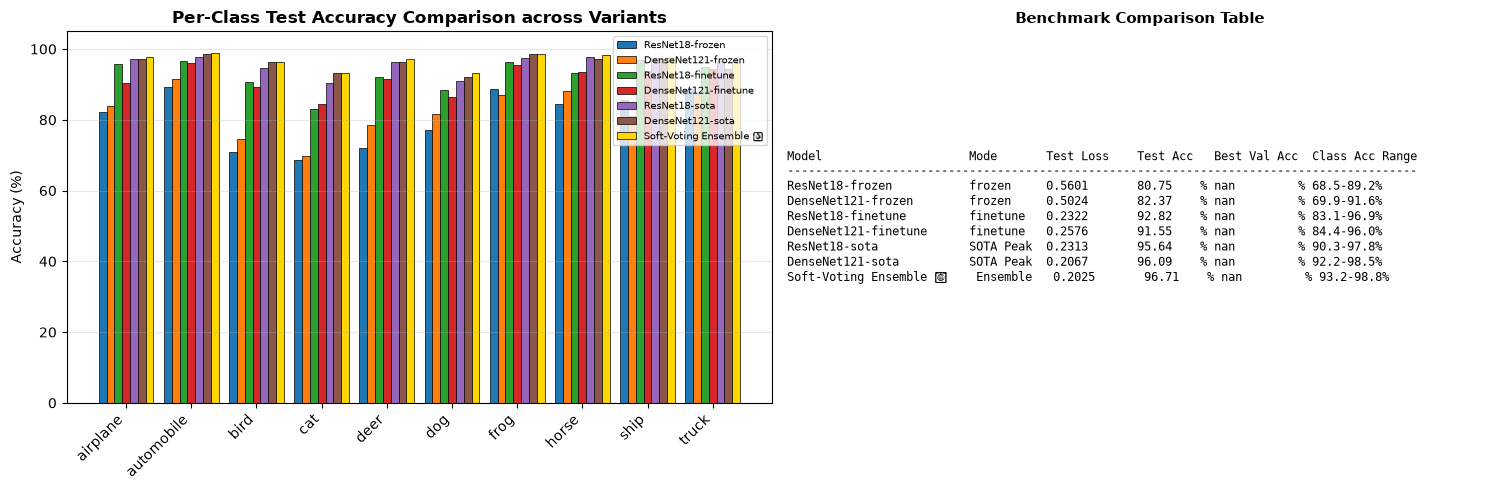

/tmp/ipykernel_172329/2901427392.py:141: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/bush/Desktop/Deeplearning_Course_UTH/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


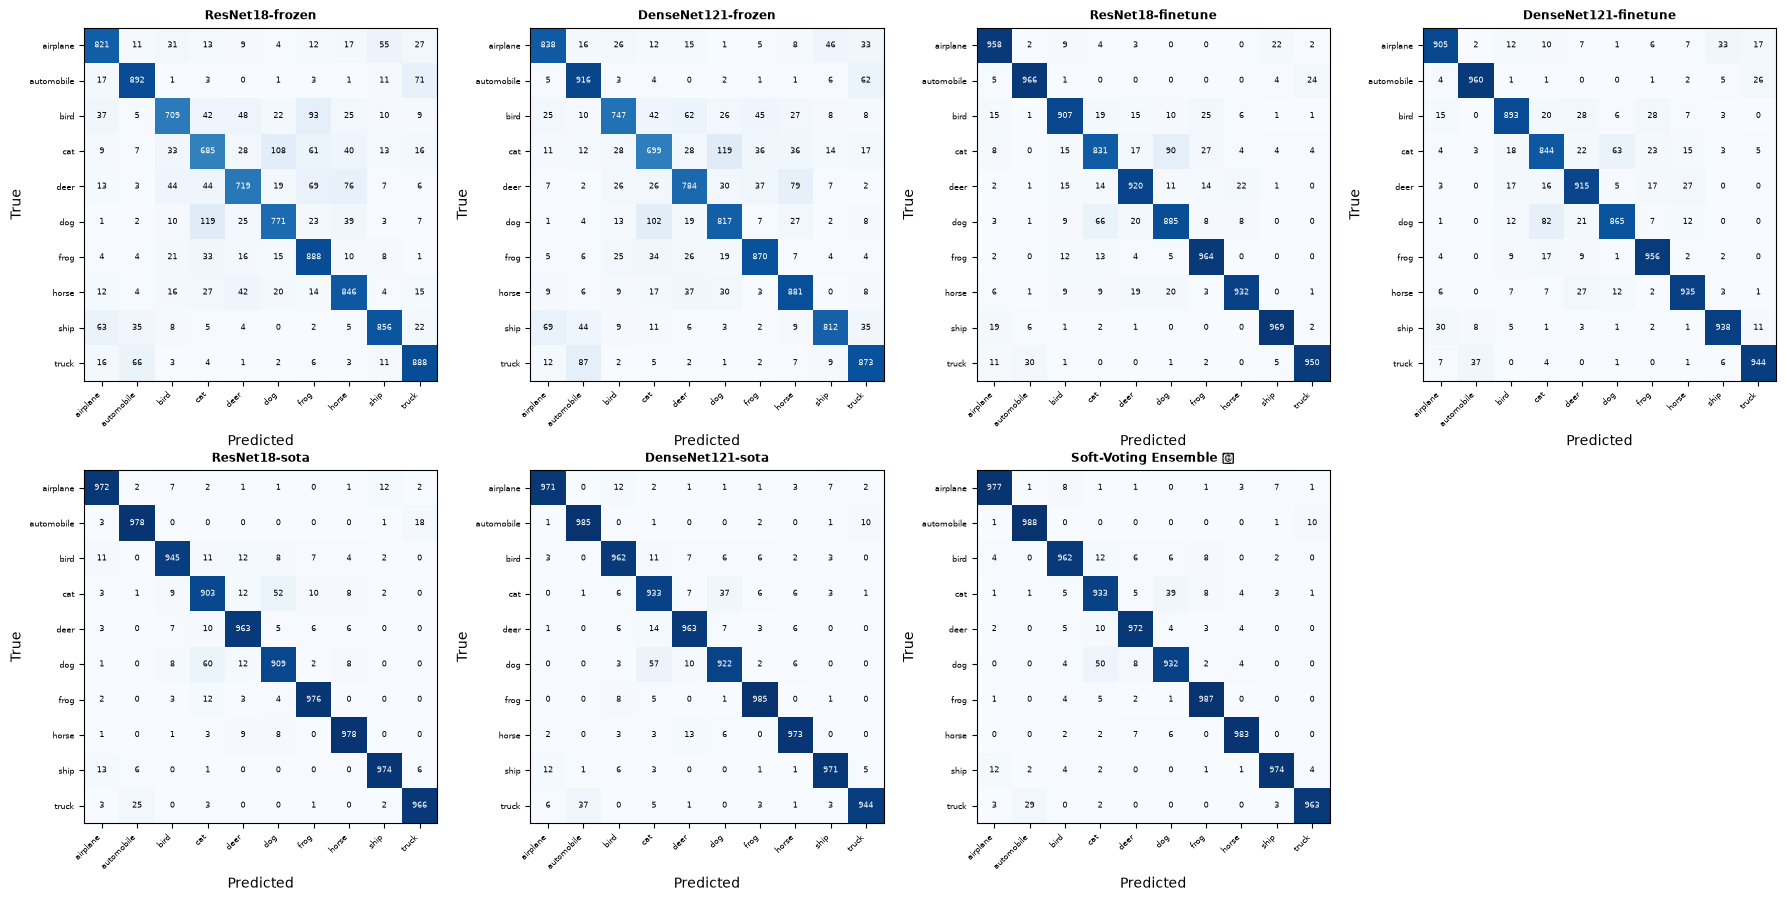

/tmp/ipykernel_172329/2901427392.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(class_names, rotation=45, ha="right")
/tmp/ipykernel_172329/2901427392.py:204: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/bush/Desktop/Deeplearning_Course_UTH/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


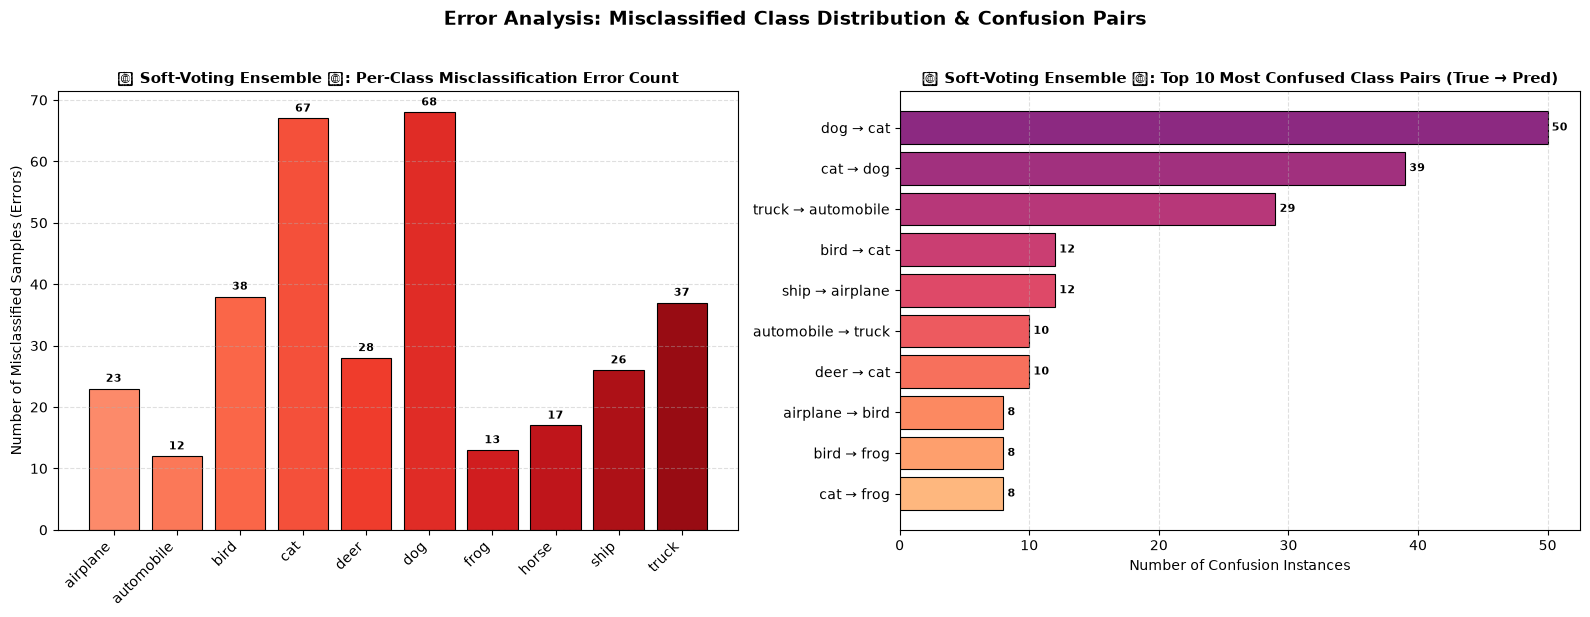

In [ ]:
# --- Chart 1: Dedicated Loss Chart per Model (Train, Val Loss together) ---
def plot_individual_model_loss_curves(training_results):
    """Plot an individual Loss chart for EACH trained model variant containing Train and Val Loss lines together."""
    n_models = len(training_results)
    cols = 3
    rows = (n_models + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
    axes = np.array(axes).flatten()

    for idx, (model_name, res) in enumerate(training_results.items()):
        ax = axes[idx]
        epochs = range(1, len(res["train_losses"]) + 1)
        train_l = res["train_losses"]
        val_l = res["val_losses"]

        # 1. Plot Train and Val Loss lines together on this model's dedicated chart
        ax.plot(epochs, train_l, "--o", color="#1f77b4", label="Train Loss", linewidth=2, markersize=5)
        ax.plot(epochs, val_l, "-s", color="#ff7f0e", label="Val Loss", linewidth=2.5, markersize=6)

        # 2. Visual Enhancement: Fill Generalization Gap between Train and Val Loss
        ax.fill_between(epochs, train_l, val_l, color="#ff7f0e", alpha=0.15, label="Generalization Gap")

        # 3. Highlight Best Epoch (Min Val Loss) with a Star Marker
        best_ep = res.get("best_epoch", int(np.argmin(val_l)) + 1)
        min_val = val_l[best_ep - 1]
        ax.scatter([best_ep], [min_val], color="red", s=120, zorder=5, marker="*", label=f"Best Ep {best_ep} ({min_val:.4f})")

        ax.set_title(f"Model: {model_name}", fontweight="bold", fontsize=11)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (Cross-Entropy)")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=8, loc="upper right")

    for idx in range(n_models, len(axes)):
        axes[idx].axis("off")

    plt.suptitle("Individual Model Loss Charts (Train vs Val Loss per Model)", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_individual_model_loss_curves(training_results)

# --- Chart 2: Dedicated Multi-Class OvR ROC Chart per Model Feature & Ensemble ---
def plot_individual_model_roc_curves(models_probs_dict, y_true, class_names):
    """Plot an individual multi-class OvR ROC chart for EACH model feature & Ensemble."""
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    n_models = len(models_probs_dict)
    
    cols = 4
    rows = (n_models + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 5 * rows))
    axes = np.array(axes).flatten()

    for idx, (model_name, probs) in enumerate(models_probs_dict.items()):
        ax = axes[idx]
        
        # Calculate Micro-Average ROC for this model
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), probs.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        
        # Plot Per-Class OvR ROC curves for all 10 CIFAR-10 classes
        for c in range(n_classes):
            fpr_c, tpr_c, _ = roc_curve(y_true_bin[:, c], probs[:, c])
            auc_c = auc(fpr_c, tpr_c)
            ax.plot(fpr_c, tpr_c, lw=1.2, alpha=0.7, label=f"{class_names[c]} ({auc_c:.3f})")

        # Plot Micro-Average ROC curve highlighted with bold black line
        ax.plot(fpr_micro, tpr_micro, "k-", lw=2.5, label=f"★ Micro-Avg ({auc_micro:.4f})")
        # Plot Random Chance diagonal line
        ax.plot([0, 1], [0, 1], "r--", lw=1.2, alpha=0.7, label="Random Chance")

        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_title(f"ROC Feature: {model_name}", fontweight="bold", fontsize=10.5)
        ax.set_xlabel("False Positive Rate (FPR)", fontsize=8)
        ax.set_ylabel("True Positive Rate (TPR)", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize=6, loc="lower right", framealpha=0.85)

    for idx in range(n_models, len(axes)):
        axes[idx].axis("off")

    plt.suptitle("Individual Multi-Class OvR ROC & Micro-AUC Charts per Model Feature", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_individual_model_roc_curves(models_probs_dict, y_true_test, CIFAR10_CLASSES)

# --- Per-Class Accuracy Grouped Bar Chart & Comparison Table ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x = np.arange(len(CIFAR10_CLASSES))
width = 0.12
colors_list = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#ffd700"]
for i, (name, res) in enumerate(eval_results.items()):
    offset = (i - 3) * width
    c = colors_list[i % len(colors_list)]
    ax.bar(x + offset, res["per_class_acc"], width, label=name, color=c, edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Test Accuracy Comparison across Variants", fontweight="bold")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 105)

ax2 = axes[1]
ax2.axis("off")
table_text = format_comparison_table(eval_results)
ax2.text(0, 0.5, table_text, fontsize=8.5, family="monospace", verticalalignment="center", transform=ax2.transAxes)
ax2.set_title("Benchmark Comparison Table", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# --- Normalized Confusion Matrix Heatmaps ---
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for idx, (name, res) in enumerate(eval_results.items()):
    ax = axes.flatten()[idx]
    cm = np.array(res["confusion_matrix"])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(CIFAR10_CLASSES)))
    ax.set_yticks(range(len(CIFAR10_CLASSES)))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=6)
    ax.set_yticklabels(CIFAR10_CLASSES, fontsize=6)
    thresh = cm_norm.max() / 2
    for r in range(len(CIFAR10_CLASSES)):
        for c in range(len(CIFAR10_CLASSES)):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=5.5,
                    color="white" if cm_norm[r, c] > thresh else "black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name, fontsize=8.5, fontweight="bold")

for idx in range(len(eval_results), 8):
    axes.flatten()[idx].axis("off")
plt.tight_layout()
plt.show()

# --- Chart 10: Misclassified Class Error Distribution & Top 10 Confused Class Pairs ---
def plot_error_distribution(eval_results, class_names):
    """Plot Misclassified Class Error Distribution & Top 10 Confused Class Pairs."""
    best_name = max(eval_results, key=lambda k: eval_results[k]["test_acc"])
    cm = np.array(eval_results[best_name]["confusion_matrix"])
    n_classes = len(class_names)

    total_per_class = cm.sum(axis=1)
    correct_per_class = np.diag(cm)
    errors_per_class = total_per_class - correct_per_class

    confused_pairs = []
    for r in range(n_classes):
        for c in range(n_classes):
            if r != c and cm[r, c] > 0:
                pair_name = f"{class_names[r]} → {class_names[c]}"
                confused_pairs.append((pair_name, cm[r, c]))
    
    confused_pairs.sort(key=lambda x: x[1], reverse=True)
    top_pairs = confused_pairs[:10]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot A: Per-Class Misclassification Error Count
    ax1 = axes[0]
    colors = plt.cm.Reds(np.linspace(0.4, 0.9, n_classes))
    bars = ax1.bar(class_names, errors_per_class, color=colors, edgecolor="black", linewidth=0.8)
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight="bold")

    ax1.set_xticklabels(class_names, rotation=45, ha="right")
    ax1.set_ylabel("Number of Misclassified Samples (Errors)")
    ax1.set_title(f"🏆 {best_name}: Per-Class Misclassification Error Count", fontweight="bold", fontsize=11)
    ax1.grid(True, linestyle="--", alpha=0.4, axis="y")

    # Subplot B: Top 10 Confused Class Pairs
    ax2 = axes[1]
    pair_names = [p[0] for p in top_pairs]
    pair_counts = [p[1] for p in top_pairs]
    colors_b = plt.cm.magma(np.linspace(0.4, 0.85, len(top_pairs)))

    bars_b = ax2.barh(pair_names[::-1], pair_counts[::-1], color=colors_b[::-1], edgecolor="black", linewidth=0.8)
    for bar in bars_b:
        width = bar.get_width()
        ax2.annotate(f'{int(width)}',
                    xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(3, 0),
                    textcoords="offset points",
                    ha='left', va='center', fontsize=8, fontweight="bold")

    ax2.set_xlabel("Number of Confusion Instances")
    ax2.set_title(f"🏆 {best_name}: Top 10 Most Confused Class Pairs (True → Pred)", fontweight="bold", fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.4, axis="x")

    plt.suptitle("Error Analysis: Misclassified Class Distribution & Confusion Pairs", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_error_distribution(eval_results, CIFAR10_CLASSES)


### 6.1 Visualize Predictions — Confused Samples Grid Only

Plot **only the misclassified (confused) test-set samples** of the top-performing
variant in a grid, each labeled with predicted vs true class and confidence.
Correct samples are intentionally excluded — error analysis focuses on where the
model fails. Images are denormalized from ImageNet statistics using:

$$\mathbf{x}_{\text{display}} = \mathbf{x}_{\text{norm}} \cdot \boldsymbol{\sigma} + \boldsymbol{\mu}$$

In [ ]:
# --- Helper: reverse ImageNet normalization for display ---
def denormalize(tensor, mean, std):
    """Denormalize ImageNet tensor back to [0, 1] range for image rendering."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

# Error analysis: collect ONLY misclassified (confused) test samples, in a grid.
if eval_results:
    best_name = max(eval_results, key=lambda k: eval_results[k]["test_acc"])
    print(f"Top performing variant for visualization: {best_name} (test acc={eval_results[best_name]['test_acc']:.2f}%)")

    best_model = rn_sota
    best_model.eval()
    misclassified = []
    N_MISCLASSIFIED = 16   # 4x4 grid of confused samples only

    with torch.no_grad():
        for images, labels in test_loader:
            images_dev, labels_dev = images.to(device), labels.to(device)
            outputs = best_model(images_dev)
            probs = torch.softmax(outputs, dim=1)
            confs, preds = probs.max(1)
            for i in range(len(images)):
                if len(misclassified) >= N_MISCLASSIFIED:
                    break
                if preds[i] != labels_dev[i]:
                    img_denorm = denormalize(images[i].cpu(), IMAGENET_MEAN, IMAGENET_STD)
                    misclassified.append((img_denorm, preds[i].item(), labels[i].item(),
                                          confs[i].item() * 100.0))
            if len(misclassified) >= N_MISCLASSIFIED:
                break

    grid_rows, grid_cols = 4, 4
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(14, 14))
    for idx, (img, pred, true, conf) in enumerate(misclassified):
        ax = axes.flatten()[idx]
        img = torch.clamp(img, 0, 1)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(f"Pred: {CIFAR10_CLASSES[pred]} ({conf:.1f}%)\nTrue: {CIFAR10_CLASSES[true]}",
                     fontsize=9, color="red", fontweight="bold")
        ax.axis("off")
    for idx in range(len(misclassified), grid_rows * grid_cols):
        axes.flatten()[idx].axis("off")
    fig.suptitle(f"{best_name}: Confused (Misclassified) Test Samples — Grid of {len(misclassified)}",
                 fontsize=13, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()
    print(f"✓ Confused-samples grid: {len(misclassified)} misclassified examples (correct ones excluded)")

## 7. Save Models & Results

Best checkpoints are persisted by the training script under
`experiments/runs/<ts>_<run_name>/checkpoints/<run_name>_best.pt`
(see `agents/rules/LOGGING_CHECKPOINT_RULES.md`). This notebook persists the
**evaluation artifacts** for reporting: the benchmark comparison text table and
JSON test metrics under `experiments/results/`.

In [ ]:
if eval_results:
    results_dir = PROJECT_ROOT / "experiments" / "results"
    os.makedirs(results_dir, exist_ok=True)
    
    table_str = format_comparison_table(eval_results)
    (results_dir / "comparison_table.txt").write_text(table_str + "\n")
    
    summary_dict = {
        name: {
            "mode": res["mode"],
            "test_loss": round(res["test_loss"], 4),
            "test_acc": round(res["test_acc"], 2),
            "per_class_acc": [round(v, 2) for v in res["per_class_acc"]],
        }
        for name, res in eval_results.items()
    }
    (results_dir / "test_metrics.json").write_text(json.dumps(summary_dict, indent=2) + "\n")
    
    history_dict = {
        name: {
            "train_losses": [round(v, 4) for v in res["train_losses"]],
            "val_losses": [round(v, 4) for v in res["val_losses"]],
            "val_accs": [round(v, 2) for v in res["val_accs"]],
            "best_epoch": res["best_epoch"],
            "best_val_acc": round(res["best_val_acc"], 2),
        }
        for name, res in training_results.items()
    }
    (results_dir / "training_history.json").write_text(json.dumps(history_dict, indent=2) + "\n")
    print(f"✓ All evaluation results & training history successfully saved to {results_dir}")
else:
    print("No evaluation results — nothing to save.")


✓ All evaluation results & training history successfully saved to /home/bush/Desktop/Deeplearning_Course_UTH/experiments/results


In [ ]:
# --- Inference cost & measured latency profiling (params, ms) ----
# Architecture cost (params), measured latency (mean+/-std), throughput
# (img/s), and test accuracy --- as a trade-off table + barplots.
import time
import statistics as st
from collections import OrderedDict
import json as _json

ckpt_dir = PROJECT_ROOT / "experiments" / "checkpoints"   # legacy flat fallback
RUNS_ROOT = PROJECT_ROOT / "experiments" / "runs"

# "sota" only unfreezes layers (trainable flags); architecture, and hence
# params/latency, is identical to "frozen", so build "frozen" and load
# the sota checkpoint (same state_dict layout).
build_mode = {"frozen": "frozen", "finetune": "finetune", "sota": "frozen"}
prof_models = OrderedDict()
for tag in ["frozen", "finetune", "sota"]:
    rn = build_resnet18(num_classes=10, mode=build_mode[tag], device=device)
    dn = build_densenet121(num_classes=10, mode=build_mode[tag], device=device)
    rp = find_best_checkpoint(f"ResNet18-{tag}", runs_root=RUNS_ROOT, fallback_dir=ckpt_dir)
    dp = find_best_checkpoint(f"DenseNet121-{tag}", runs_root=RUNS_ROOT, fallback_dir=ckpt_dir)
    if rp is not None: rn = load_model_weights(rn, rp, device)
    if dp is not None: dn = load_model_weights(dn, dp, device)
    prof_models[f"ResNet18-{tag}"] = rn.eval()
    prof_models[f"DenseNet121-{tag}"] = dn.eval()

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def measure_latency(model, bs=64, warmup=10, iters=50):
    model.eval()
    x = torch.randn(bs, 3, 224, 224, device=device)
    with torch.no_grad():
        for _ in range(warmup): model(x)
    if device.type == "cuda": torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(iters):
            t0 = time.perf_counter()
            model(x)
            if device.type == "cuda": torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000.0)
    return st.mean(times), (st.stdev(times) if len(times) > 1 else 0.0)

BATCH = 64

# Load test accuracy from saved eval metrics (test_metrics.json)
_acc = {}
_mpath = PROJECT_ROOT / "experiments" / "results" / "test_metrics.json"
if _mpath.exists():
    _m = _json.loads(_mpath.read_text())
    for _k, _v in _m.items():
        _acc[_k] = _v.get("test_acc", float("nan"))
def acc_for(name):
    key = "Soft-Voting Ensemble \U0001F3C6" if "Ensemble" in name else name
    return _acc.get(key, float("nan"))

rows = []
params_map = {}
for name, model in prof_models.items():
    params_map[name] = count_params(model)
    lm, ls = measure_latency(model, bs=BATCH)
    tp = BATCH / (lm / 1000.0)                       # images / second
    rows.append((name, params_map[name] / 1e6, lm, ls, tp, acc_for(name)))

# Ensemble = soft-voting over the two SOTA experts
rn_s, dn_s = prof_models["ResNet18-sota"], prof_models["DenseNet121-sota"]
ens_params = (params_map["ResNet18-sota"] + params_map["DenseNet121-sota"]) / 1e6
x = torch.randn(BATCH, 3, 224, 224, device=device)
rn_s.eval(); dn_s.eval()
with torch.no_grad():
    for _ in range(10): torch.softmax(rn_s(x), 1); torch.softmax(dn_s(x), 1)
if device.type == "cuda": torch.cuda.synchronize()
ens_times = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.perf_counter()
        pa = torch.softmax(rn_s(x), 1); pb = torch.softmax(dn_s(x), 1)
        _ = 0.5 * (pa + pb)
        if device.type == "cuda": torch.cuda.synchronize()
        ens_times.append((time.perf_counter() - t0) * 1000.0)
ens_lm, ens_ls = st.mean(ens_times), st.stdev(ens_times)
rows.append(("Soft-Voting Ensemble (SOTA x2)", ens_params, ens_lm, ens_ls,
             BATCH / (ens_lm / 1000.0), acc_for("Soft-Voting Ensemble (SOTA x2)")))

print(f"Profiling on {device} | batch={BATCH} | input 3x224x224")
print()
print(f"{'Model':34s} {'Par(M)':>7s} {'Acc%':>6s} {'img/s':>8s} {'Lat(ms)':>13s}")
for name, p, lm, ls, tp, acc in rows:
    print(f"{name:34s} {p:>6.1f}M {acc:>5.2f}% {tp:>7.0f} {lm:>8.1f} +/- {ls:.1f}")

# ---- Barplots: params, measured latency, test accuracy ----
single = [r for r in rows if r[1] is not None]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) params
names = [r[0] for r in single]
params = [r[1] for r in single]
x = np.arange(len(names))
axes[0].bar(x, params, 0.5, label="Params (M)", color="#1f77b4", edgecolor="black")
for i in range(len(names)):
    axes[0].text(i, params[i], f"{params[i]:.1f}", ha="center", va="bottom", fontsize=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=30, ha="right", fontsize=6)
axes[0].set_title("Architecture cost (params)")
axes[0].legend(fontsize=7); axes[0].grid(True, axis="y", alpha=0.3)

# 2) measured latency
all_names = [r[0] for r in rows]
lat = [r[2] for r in rows]; lat_std = [r[3] for r in rows]
xc = np.arange(len(all_names))
axes[1].bar(xc, lat, 0.6, color="#2ca02c", edgecolor="black", yerr=lat_std, capsize=3)
for i in range(len(all_names)):
    axes[1].text(i, lat[i], f"{lat[i]:.1f}\u00b1{lat_std[i]:.1f}", ha="center", va="bottom", fontsize=7)
axes[1].set_xticks(xc); axes[1].set_xticklabels(all_names, rotation=30, ha="right", fontsize=6)
axes[1].set_ylabel("ms"); axes[1].set_title(f"Measured latency (mean \u00b1 std, batch={BATCH})")
axes[1].grid(True, axis="y", alpha=0.3)

# 3) test accuracy
accs = [r[5] for r in rows]
axes[2].bar(xc, accs, 0.6, color="#9467bd", edgecolor="black")
for i in range(len(all_names)):
    axes[2].text(i, accs[i], f"{accs[i]:.2f}", ha="center", va="bottom", fontsize=7)
axes[2].set_xticks(xc); axes[2].set_xticklabels(all_names, rotation=30, ha="right", fontsize=6)
axes[2].set_ylabel("%"); axes[2].set_title("Test accuracy (%)")
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()